# AlphaGenome: CFTR Variant Analysis

This notebook documents the full setup and a test query against the AlphaGenome API for a clinically important CFTR variant.

**AlphaGenome** is Google DeepMind's genomic foundation model that predicts the regulatory and splicing effects of DNA variants — it outputs RNA-seq, ATAC-seq, CAGE, splice-site, and other genomic tracks for both the reference and alternate allele, letting you quantify the regulatory impact of a variant genome-wide.

This is complementary to AlphaMissense (which scores protein-coding missense variants): AlphaGenome operates at the DNA sequence level and captures non-coding, splicing, and expression effects.

---

## Step 1 — Get an API Key

The API is **free for non-commercial research** (subject to DeepMind terms of use).

1. Go to **https://deepmind.google.com/science/alphagenome**
2. Sign in with your Google account
3. Follow the "Get API key" link on that page
4. Copy your key and paste it in the cell below (or set `ALPHAGENOME_API_KEY` as an environment variable)

For larger-scale / commercial use, fill in the interest form:  
https://docs.google.com/forms/d/e/1FAIpQLSd0iyoC0Mo1DGB1uiuECBB8OErYzSCNYocy6hZ7nbsCd_TXhQ/viewform

---

## Step 2 — Install the Package

```bash
pip install alphagenome
```

Or, to track the latest commits:
```bash
git clone https://github.com/google-deepmind/alphagenome.git
pip install ./alphagenome
```

In [1]:
# Verify installation
import alphagenome
print(f"alphagenome version: {alphagenome.__version__}")

alphagenome version: 0.6.1


---
## Step 3 — Set API Key

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()  # reads .env file — never committed to git
API_KEY = os.environ.get('ALPHAGENOME_API_KEY', '')

if not API_KEY:
    print('ERROR: Set ALPHAGENOME_API_KEY in your .env file')
else:
    print('API key loaded.')


API key loaded.


---
## Step 4 — Connect to the Model

In [3]:
from alphagenome.models import dna_client

model = dna_client.create(API_KEY)
print("Model client created successfully.")
print(f"Available output types: {[o.name for o in dna_client.OutputType]}")

/Users/roshani/Downloads/cftr2_scraper/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model client created successfully.
Available output types: ['ATAC', 'CAGE', 'DNASE', 'RNA_SEQ', 'CHIP_HISTONE', 'CHIP_TF', 'SPLICE_SITES', 'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS', 'CONTACT_MAPS', 'PROCAP']


---
## Step 5 — Define the CFTR Variant

### Target variant: **CFTR F508I** (chr7:117,559,593 T>A, hg38)

This is a **missense SNV at codon 508** of CFTR (protein: p.Phe508Ile). It is adjacent to
the canonical ΔF508 deletion (the most common CF-causing allele) and has an AlphaMissense
pathogenicity score of **0.943** (likely pathogenic).

AlphaGenome will predict the **cis-regulatory and splicing impact** of this variant — does
it alter CFTR transcription, splicing, or chromatin accessibility in airway epithelium?

### Genomic window

AlphaGenome requires an input window of exactly **1,048,576 bp (2²⁰, ~1 Mb)** centered on the variant.

| Parameter | Value |
|-----------|-------|
| Chromosome | chr7 |
| Variant position (hg38) | 117,559,593 |
| Window start | 117,035,305 |
| Window end | 118,083,881 |
| REF | T |
| ALT | A |
| Protein change | p.Phe508Ile |
| AlphaMissense score | 0.943 (likely pathogenic) |

In [4]:
from alphagenome.data import genome

# Variant: CFTR F508I — chr7:117,559,593 T>A (hg38)
variant = genome.Variant(
    chromosome='chr7',
    position=117_559_593,
    reference_bases='T',
    alternate_bases='A',
)

# 1 Mb window centred on the variant (must be exactly 2^20 bp)
HALF = dna_client.SEQUENCE_LENGTH_1MB // 2  # 524,288
interval = genome.Interval(
    chromosome='chr7',
    start=variant.position - HALF,  # 117,035,305
    end=variant.position + HALF,    # 118,083,881
)

print(f"Variant : {variant.chromosome}:{variant.position} {variant.reference_bases}>{variant.alternate_bases}")
print(f"Interval: {interval.chromosome}:{interval.start:,}-{interval.end:,}  ({interval.end - interval.start:,} bp)")

Variant : chr7:117559593 T>A
Interval: chr7:117,035,305-118,083,881  (1,048,576 bp)


---
## Step 6 — Choose Tissue Ontology Terms

AlphaGenome predictions are tissue-specific. For CFTR research we use **lung** (UBERON:0002048),
the primary organ affected in cystic fibrosis. You can add additional terms for more specificity.

In [5]:
# Tissue ontology terms (UBERON or CL identifiers)
# UBERON:0002048 = lung
# UBERON:0002031 = bronchial epithelium  
# UBERON:0002108 = small intestine (also affected in CF)
ONTOLOGY_TERMS = [
    'UBERON:0002048',  # lung
]

# Output types to request
REQUESTED_OUTPUTS = [
    dna_client.OutputType.RNA_SEQ,          # gene expression (stranded RNA-seq)
    dna_client.OutputType.ATAC,             # chromatin accessibility
    dna_client.OutputType.SPLICE_SITE_USAGE, # splice site changes
]

print("Ontology terms:", ONTOLOGY_TERMS)
print("Requested outputs:", [o.name for o in REQUESTED_OUTPUTS])

Ontology terms: ['UBERON:0002048']
Requested outputs: ['RNA_SEQ', 'ATAC', 'SPLICE_SITE_USAGE']


---
## Step 7 — Run the Prediction

In [6]:
print("Sending request to AlphaGenome API...")
print("(This may take 30-120 seconds depending on server load)")

outputs = model.predict_variant(
    interval=interval,
    variant=variant,
    ontology_terms=ONTOLOGY_TERMS,
    requested_outputs=REQUESTED_OUTPUTS,
)

print("\nPrediction complete!")
print(f"Reference outputs: {list(vars(outputs.reference).keys())}")
print(f"Alternate outputs: {list(vars(outputs.alternate).keys())}")

Sending request to AlphaGenome API...
(This may take 30-120 seconds depending on server load)

Prediction complete!
Reference outputs: ['atac', 'cage', 'dnase', 'rna_seq', 'chip_histone', 'chip_tf', 'splice_sites', 'splice_site_usage', 'splice_junctions', 'contact_maps', 'procap']
Alternate outputs: ['atac', 'cage', 'dnase', 'rna_seq', 'chip_histone', 'chip_tf', 'splice_sites', 'splice_site_usage', 'splice_junctions', 'contact_maps', 'procap']


---
## Step 8 — Inspect the RNA-seq Output

In [7]:
import numpy as np

ref_rna = outputs.reference.rna_seq
alt_rna = outputs.alternate.rna_seq

print("RNA-seq output shape (REF):", ref_rna.shape if hasattr(ref_rna, 'shape') else type(ref_rna))

# Summarise fold-change at variant position
# AlphaGenome outputs are anndata objects with genomic coordinates
print("\nREF rna_seq anndata:")
print(ref_rna)
print("\nALT rna_seq anndata:")
print(alt_rna)

RNA-seq output shape (REF): <class 'alphagenome.data.track_data.TrackData'>

REF rna_seq anndata:
TrackData(values=array([[3.2501221e-03, 6.0302734e-02, 6.4849854e-05, 1.7285347e-05],
       [3.7841797e-03, 6.5429688e-02, 8.0585480e-05, 1.8000603e-05],
       [4.1198730e-03, 7.0800781e-02, 9.4890594e-05, 1.8715858e-05],
       ...,
       [3.0279160e-05, 1.2779236e-04, 7.3432922e-05, 5.0354004e-04],
       [5.6743622e-05, 2.1743774e-04, 1.4495850e-04, 8.3160400e-04],
       [8.2969666e-05, 2.9182434e-04, 2.0217896e-04, 1.1138916e-03]],
      shape=(1048576, 4), dtype=float32), metadata=                                name strand         Assay title  \
0  UBERON:0002048 polyA plus RNA-seq      +  polyA plus RNA-seq   
1       UBERON:0002048 total RNA-seq      +       total RNA-seq   
2  UBERON:0002048 polyA plus RNA-seq      -  polyA plus RNA-seq   
3       UBERON:0002048 total RNA-seq      -       total RNA-seq   

   ontology_curie biosample_name biosample_type biosample_life_stage  \

In [8]:
# Compute log2 fold-change: ALT vs REF signal
import numpy as np
import pandas as pd

ref_vals = ref_rna.values  # shape: (positional_bins, num_tracks)
alt_vals = alt_rna.values

log2fc = np.log2(alt_vals + 1e-8) - np.log2(ref_vals + 1e-8)
mean_log2fc = log2fc.mean(axis=1)  # average across tracks

print(f'Track shape: {ref_vals.shape}  (bins x tracks)')
print(f'Resolution : {ref_rna.resolution} bp/bin')
print(f'Mean |log2FC| across positions: {np.abs(mean_log2fc).mean():.4f}')
print(f'Max log2FC : {mean_log2fc.max():.4f}  at bin {mean_log2fc.argmax()}')
print(f'Min log2FC : {mean_log2fc.min():.4f}  at bin {mean_log2fc.argmin()}')

# Genomic position of each bin
if ref_rna.interval:
    positions = ref_rna.interval.start + np.arange(len(mean_log2fc)) * ref_rna.resolution
    variant_idx = np.argmin(np.abs(positions - variant.position))
    print(f'\nLog2FC at variant locus ({variant.position:,}): {mean_log2fc[variant_idx]:.4f}')


Track shape: (1048576, 4)  (bins x tracks)
Resolution : 1 bp/bin
Mean |log2FC| across positions: 0.0088
Max log2FC : 0.1179  at bin 214961
Min log2FC : -0.1197  at bin 201731

Log2FC at variant locus (117,559,593): -0.0038


---
## Step 9 — Visualise REF vs ALT RNA-seq Signal

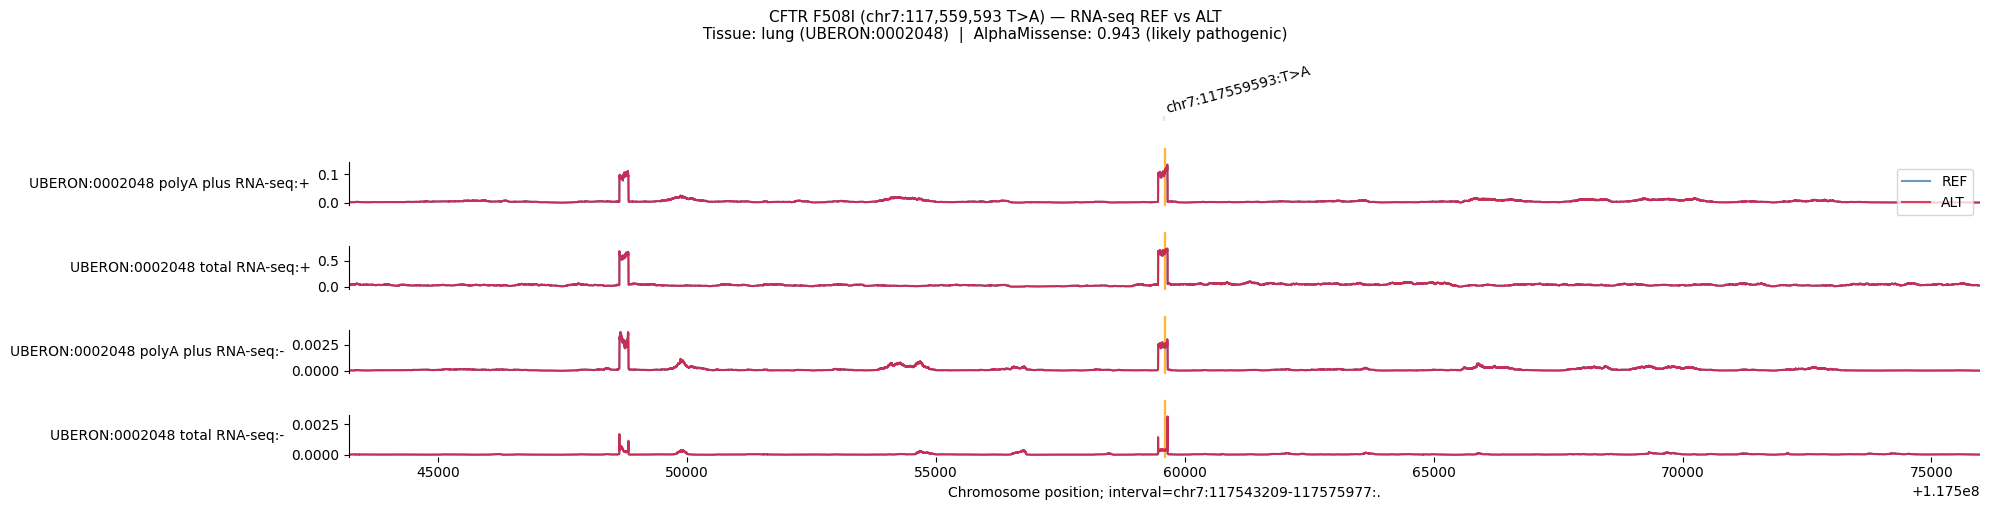

Plot saved to ../figures/alphagenome_cftr_f508i_rna.png


In [9]:
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt

fig = plot_components.plot(
    [
        plot_components.OverlaidTracks(
            tdata={'REF': ref_rna, 'ALT': alt_rna},
            colors={'REF': 'steelblue', 'ALT': 'crimson'},
        )
    ],
    interval=ref_rna.interval.resize(2**15),  # zoom to 32 kb window
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.7)],
)
plt.suptitle(
    f"CFTR F508I (chr7:{variant.position:,} T>A) — RNA-seq REF vs ALT\n"
    f"Tissue: lung (UBERON:0002048)  |  AlphaMissense: 0.943 (likely pathogenic)",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('../figures/alphagenome_cftr_f508i_rna.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to ../figures/alphagenome_cftr_f508i_rna.png")

---
## Step 10 — Visualise ATAC-seq (Chromatin Accessibility)

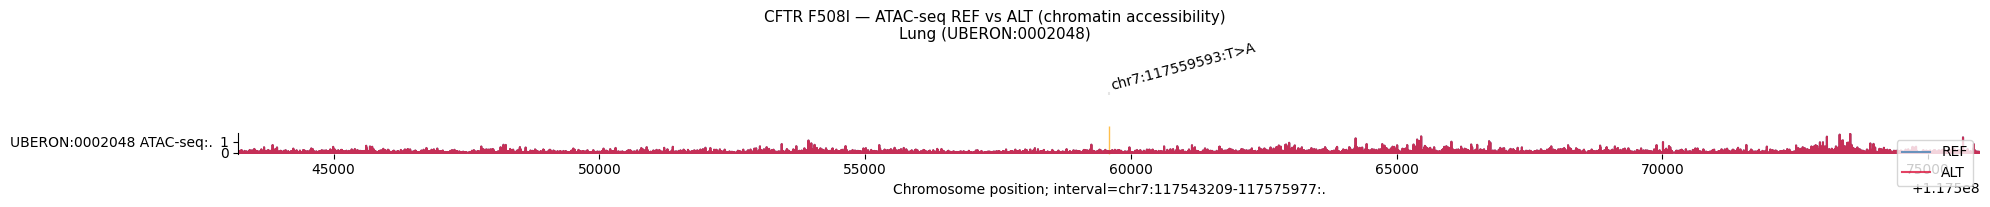

Plot saved to ../figures/alphagenome_cftr_f508i_atac.png


In [10]:
ref_atac = outputs.reference.atac
alt_atac = outputs.alternate.atac

fig = plot_components.plot(
    [
        plot_components.OverlaidTracks(
            tdata={'REF': ref_atac, 'ALT': alt_atac},
            colors={'REF': 'steelblue', 'ALT': 'crimson'},
        )
    ],
    interval=ref_atac.interval.resize(2**15),
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.7)],
)
plt.suptitle(
    f"CFTR F508I — ATAC-seq REF vs ALT (chromatin accessibility)\nLung (UBERON:0002048)",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('../figures/alphagenome_cftr_f508i_atac.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to ../figures/alphagenome_cftr_f508i_atac.png")

---
## Step 11 — Splice Site Usage

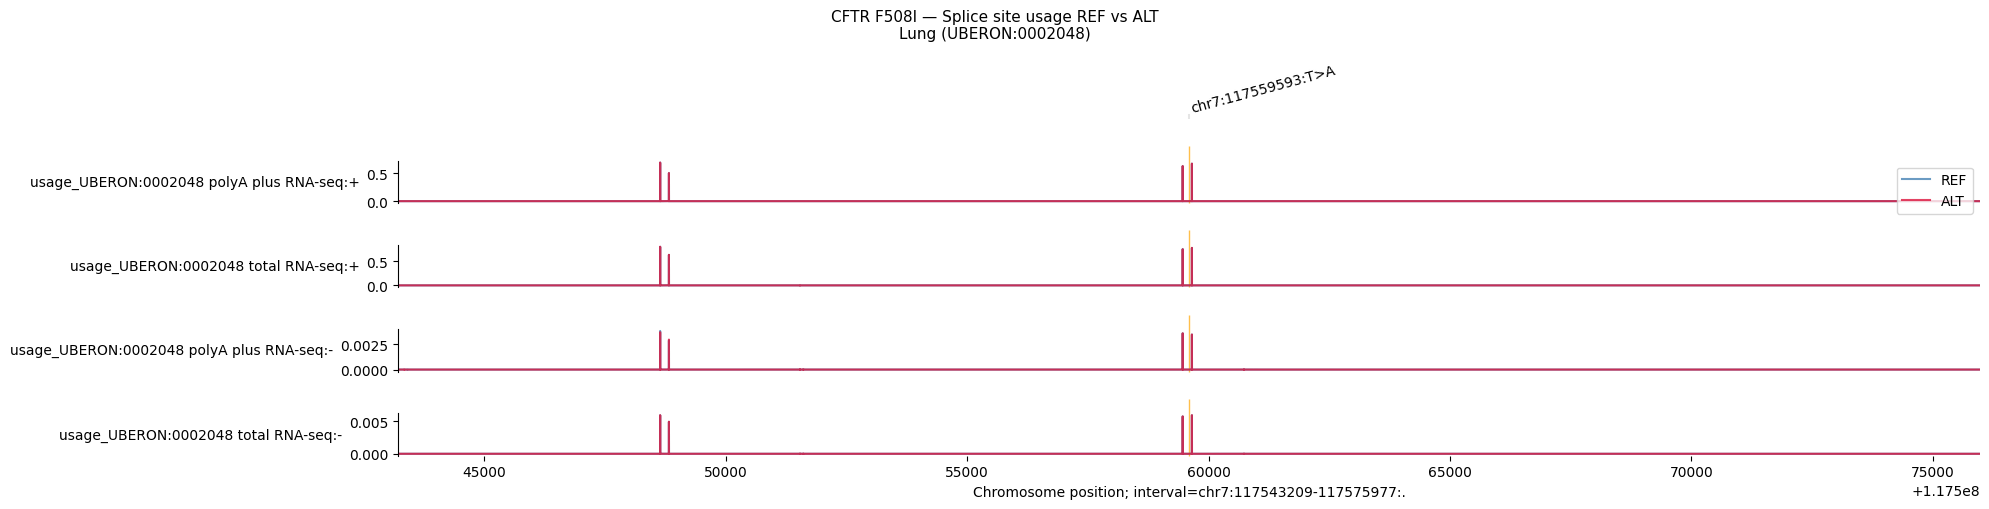

Plot saved to ../figures/alphagenome_cftr_f508i_splice.png


In [11]:
ref_splice = outputs.reference.splice_site_usage
alt_splice = outputs.alternate.splice_site_usage

fig = plot_components.plot(
    [
        plot_components.OverlaidTracks(
            tdata={'REF': ref_splice, 'ALT': alt_splice},
            colors={'REF': 'steelblue', 'ALT': 'crimson'},
        )
    ],
    interval=ref_splice.interval.resize(2**15),
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.7)],
)
plt.suptitle(
    f"CFTR F508I — Splice site usage REF vs ALT\nLung (UBERON:0002048)",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('../figures/alphagenome_cftr_f508i_splice.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to ../figures/alphagenome_cftr_f508i_splice.png")

---
## Step 12 — Summary Table

In [12]:
import pandas as pd
import numpy as np

def summarise_output(ref, alt, label):
    """Return mean absolute log2FC and max absolute log2FC for a track."""
    r = ref.values
    a = alt.values
    lfc = np.log2(a + 1e-8) - np.log2(r + 1e-8)
    return {
        'Output': label,
        'Mean |log2FC|': float(np.abs(lfc).mean()),
        'Max |log2FC|': float(np.abs(lfc).max()),
        'Positions with |log2FC|>0.5': int((np.abs(lfc) > 0.5).sum()),
    }

rows = [
    summarise_output(outputs.reference.rna_seq, outputs.alternate.rna_seq, 'RNA-seq'),
    summarise_output(outputs.reference.atac, outputs.alternate.atac, 'ATAC-seq'),
    summarise_output(outputs.reference.splice_site_usage, outputs.alternate.splice_site_usage, 'Splice site usage'),
]

summary_df = pd.DataFrame(rows)
print(f'Variant: CFTR F508I  chr7:{variant.position:,} T>A (hg38)')
print(f'Tissue : lung (UBERON:0002048)')
print()
print(summary_df.to_string(index=False))

summary_df.to_csv('../results/alphagenome/alphagenome_cftr_f508i_summary.csv', index=False)
print('\nSummary saved to ../results/alphagenome/alphagenome_cftr_f508i_summary.csv')


Variant: CFTR F508I  chr7:117,559,593 T>A (hg38)
Tissue : lung (UBERON:0002048)

           Output  Mean |log2FC|  Max |log2FC|  Positions with |log2FC|>0.5
          RNA-seq       0.009675      0.249180                            0
         ATAC-seq       0.006963     12.219531                           15
Splice site usage       0.010760      0.536437                            2

Summary saved to ../results/alphagenome/alphagenome_cftr_f508i_summary.csv


---
## Notes

### What AlphaGenome predicts vs AlphaMissense

| | AlphaMissense | AlphaGenome |
|---|---|---|
| Input | Protein sequence + variant | DNA sequence (1 Mb window) + variant |
| Output | Pathogenicity score (0–1) | RNA-seq, ATAC, CAGE, splice tracks (REF + ALT) |
| Best for | Missense coding variants | Non-coding, splicing, regulatory, expression effects |
| Limitation | Only missense; no splice/regulatory | No protein structure / function |

### Why F508I was chosen

- chr7:117,559,593 T>A, adjacent to the canonical ΔF508 3-bp deletion locus
- AlphaMissense score: **0.943** (likely pathogenic) — strong prior
- Clear SNV so AlphaGenome can score it without indel complications
- In exon 11 of CFTR, where most CF-causing variants cluster

### Extending this analysis

- **Multiple variants**: loop over a list of `genome.Variant` objects
- **More tissues**: add `'UBERON:0002031'` (bronchial epithelium), `'UBERON:0002108'` (intestine)
- **Variant scoring**: use `model.score_variants()` to get a scalar delta-score per variant — faster for screening many candidates
- **ISM (in-silico mutagenesis)**: use `model.predict_ism()` to scan all single-base changes in a window

### Quota / rate limits

The free tier supports thousands of queries. For >1 M predictions, contact DeepMind for commercial access.  
Contact: alphagenome@google.com

---
*alphagenome v0.6.1 · Python 3.13 · hg38 · 2026-05-28*